In [11]:
#[Please use Google Colab or any Python Environment to complete this tutorial]

# Reference:

# https://medium.com/data-science/sentiment-analysis-of-tweets-using-multinomial-naive-bayes-1009ed24276b

In [12]:
# Text Classification Tutorial - Sentiment Analysis
#  Lab7 Tutorial

# 1. Import Required Libraries
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
# 2. Load and Preprocess Data
# Sample dataset for sentiment classification
data = {
    "text": [
        "I love this product. It's amazing!",
        "Terrible experience. I hate it.",
        "Absolutely fantastic! Highly recommend.",
        "Worst product ever. Do not buy.",
        "I'm very satisfied with this purchase.",
        "Horrible, waste of money."
    ],
    "label": ["positive", "negative", "positive", "negative", "positive", "negative"]

    #"label": [1, 0, 1, 0, 1, 0]  # 1 = positive, 0 = negative
}
# Create DataFrame
df = pd.DataFrame(data)
print("Dataset:")
print(df)
print("\n")

Dataset:
                                      text     label
0       I love this product. It's amazing!  positive
1          Terrible experience. I hate it.  negative
2  Absolutely fantastic! Highly recommend.  positive
3          Worst product ever. Do not buy.  negative
4   I'm very satisfied with this purchase.  positive
5                Horrible, waste of money.  negative




In [14]:
# 3. Convert Text Data into Features
# Initialize TfidfVectorizer
tfidf = TfidfVectorizer()

# Transform the text data
X = tfidf.fit_transform(df['text'])

# Labels
y = df['label']

print(f"Feature matrix shape: {X.shape}")
print(f"Number of features (unique words): {len(tfidf.get_feature_names_out())}")
print("Features (vocabulary):", tfidf.get_feature_names_out())
print("\n")

Feature matrix shape: (6, 25)
Number of features (unique words): 25
Features (vocabulary): ['absolutely' 'amazing' 'buy' 'do' 'ever' 'experience' 'fantastic' 'hate'
 'highly' 'horrible' 'it' 'love' 'money' 'not' 'of' 'product' 'purchase'
 'recommend' 'satisfied' 'terrible' 'this' 'very' 'waste' 'with' 'worst']




In [15]:
# 4. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print("\n")

Training set size: 4 samples
Testing set size: 2 samples




In [16]:
# 5. Train a Classifier
# Initialize and train Multinomial Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train, y_train)

print("Model training completed!")
print("\n")

Model training completed!




In [ ]:
# 6. Evaluate the Model
# Predict on the test set and evaluate performance.

# Predict on the test data
y_pred = model.predict(X_test)

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       1.0
    positive       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0

Accuracy: 0.00



Confusion Matrix:
[[0 1]
 [1 0]]


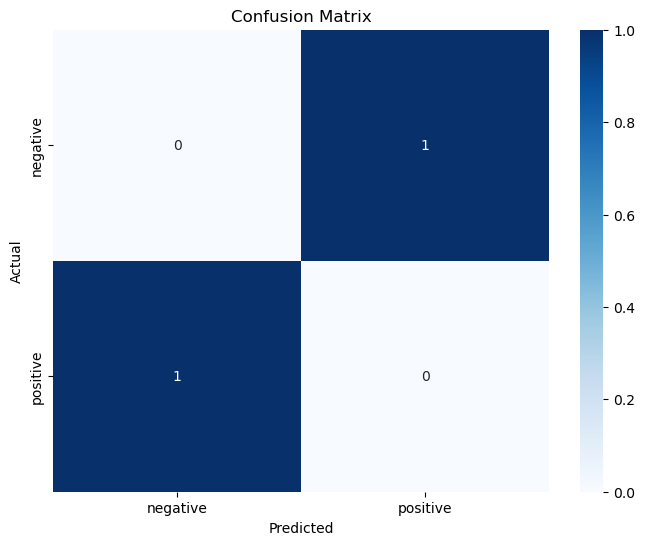

In [18]:
# Additional Evaluation: Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['negative', 'positive'], 
            yticklabels=['negative', 'positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [19]:
# Make predictions on new text samples
print("\n" + "="*50)
print("Testing with new samples:")
print("="*50)

new_texts = [
    "This product is excellent! Very happy with it.",
    "Not good at all. Very disappointed.",
    "Average product, nothing special."
]
# Transform new texts using the same vectorizer
new_texts_transformed = tfidf.transform(new_texts)

# Make predictions
new_predictions = model.predict(new_texts_transformed)
new_probabilities = model.predict_proba(new_texts_transformed)


Testing with new samples:


In [20]:
for text, pred, prob in zip(new_texts, new_predictions, new_probabilities):
    sentiment = "Positive" if pred == 1 else "Negative"
    confidence = max(prob) * 100
    print(f"\nText: '{text}'")
    print(f"Predicted sentiment: {sentiment} (confidence: {confidence:.2f}%)")
    print(f"Class probabilities: Negative={prob[0]:.3f}, Positive={prob[1]:.3f}")

# Model Analysis
print("\n" + "="*50)
print("Model Analysis:")
print("="*50)


Text: 'This product is excellent! Very happy with it.'
Predicted sentiment: Negative (confidence: 56.46%)
Class probabilities: Negative=0.435, Positive=0.565

Text: 'Not good at all. Very disappointed.'
Predicted sentiment: Negative (confidence: 50.77%)
Class probabilities: Negative=0.492, Positive=0.508

Text: 'Average product, nothing special.'
Predicted sentiment: Negative (confidence: 57.17%)
Class probabilities: Negative=0.572, Positive=0.428

Model Analysis:


In [21]:
# Get feature names and their log probabilities
feature_names = tfidf.get_feature_names_out()
class_labels = ['negative', 'positive']

# Display top features for each class
for i, class_label in enumerate(class_labels):
    # Get log probabilities for this class
    log_probs = model.feature_log_prob_[i]
    
    # Get top 5 features with highest probability
    top_indices = log_probs.argsort()[-5:][::-1]
    top_features = [(feature_names[idx], log_probs[idx]) for idx in top_indices]
    
    print(f"\nTop 5 features for {class_label} class:")
    for feature, prob in top_features:
        print(f"  {feature}: {prob:.3f}")


Top 5 features for negative class:
  terrible: -2.962
  hate: -2.962
  experience: -2.962
  it: -3.026
  worst: -3.032

Top 5 features for positive class:
  recommend: -2.970
  fantastic: -2.970
  absolutely: -2.970
  highly: -2.970
  purchase: -2.995
